# Experimental: Agent CBL Packet From One Prompt

This notebook is a packet-scale stress test for the public `wellplot.agent` API.
It stages the two DLIS inputs used by `examples/production/cbl_log_example`, boots a
cased-hole starter scaffold, and asks the agent to build the supported packet subset
from one structured prompt.

Use this notebook to test the staged packet planner, deterministic header fill, section
replication, and per-phase preview reporting. It is intentionally more demanding than
`agent_las_step_by_step.ipynb` and is not the primary end-user walkthrough.

In [1]:
import os
import sys
from pathlib import Path

try:
    import wellplot
except ImportError as exc:
    raise RuntimeError(
        "Install the published 'wellplot' package in the active environment before running this notebook."
    ) from exc

from wellplot.agent import (
    create_project_session,
    display_authoring_result,
    relative_path,
)

# Walk upward from the current working directory until we find the
# repository checkout that holds the example sources and sample data.
cwd = Path.cwd().resolve()
REPO_ROOT = next((path for path in (cwd, *cwd.parents) if (path / "examples").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError(
        "Run this notebook from a checkout of the wellplot repository "
        "so the example files and sample data are available."
    )

# Select one supported agent. Change only this value when switching models.
AGENT_OPTION = os.getenv("WELLPLOT_AGENT_OPTION", "nvidia_cloud")
AGENT_OPTIONS = {
    "openai": {
        "provider": "openai",
        "model": "gpt-5.4",
        "base_url": None,
        "key_file": None,
        "key_env": "OPENAI_API_KEY",
    },
    "unsloth": {
        "provider": "openai_compat",
        "model": "unsloth/Qwen3.8-27B-GGUF:UD-Q4_K_XL",
        "base_url": "http://192.168.2.140:8888/v1",
        "key_file": "UNSLOTH_API_KEY.txt",
        "key_env": "UNSLOTH_API_KEY",
    },
    "ollama": {
        "provider": "ollama",
        "model": "llama3.2",
        "base_url": "http://localhost:11434/v1",
        "key_file": None,
        "key_env": None,
    },
    "nvidia_cloud": {
        "provider": "openai_compat",
        "model": "nvidia/nemotron-3-super-120b-a12b",
        "base_url": "https://integrate.api.nvidia.com/v1",
        "key_file": "NVIDIA_API_KEY.txt",
        "key_env": "NVIDIA_API_KEY",
    },
    "nvidia_glm": {
        "provider": "openai_compat",
        "model": "z-ai/glm-5.2",
        "base_url": "https://integrate.api.nvidia.com/v1",
        "key_file": "NVIDIA_API_KEY.txt",
        "key_env": "NVIDIA_API_KEY",
    },
    "openrouter": {
        "provider": "openai_compat",
        "model": "stealth/ox-alpha",
        "base_url": "https://openrouter.ai/api/v1",
        "key_file": "OPENROUTER_API_KEY.txt",
        "key_env": "OPENROUTER_API_KEY",
    },
    "unsloth_backup": {
        "provider": "openai_compat",
        "model": "unsloth/Qwen3.8-27B-GGUF:UD-Q4_K_XL",
        "base_url": "http://79.110.54.14:8888/v1",
        "key_file": "UNSLOTH_API_KEY.txt",
        "key_env": "UNSLOTH_API_KEY",
    },
}
if AGENT_OPTION not in AGENT_OPTIONS:
    raise ValueError(
        f"Unknown AGENT_OPTION={AGENT_OPTION!r}. Choose one of: "
        f"{', '.join(AGENT_OPTIONS)}"
    )
AGENT_CONFIG = AGENT_OPTIONS[AGENT_OPTION]

def _load_agent_key(file_name: str | None, env_name: str | None) -> str | None:
    """Read the selected local token without displaying or persisting it."""
    if env_name:
        token = os.getenv(env_name, "").strip()
        if token:
            return token
    if not file_name:
        return None
    key_path = REPO_ROOT / file_name
    if not key_path.exists():
        return None
    return key_path.read_text(encoding="utf-8").strip() or None

PROVIDER = AGENT_CONFIG["provider"]
MODEL = AGENT_CONFIG["model"]
BASE_URL = AGENT_CONFIG["base_url"]
API_KEY = _load_agent_key(AGENT_CONFIG["key_file"], AGENT_CONFIG["key_env"])
PROJECT_DIR = REPO_ROOT / "workspace" / "tutorials" / "agent_cbl_log_example_from_prompt"
session, paths = create_project_session(
    server_root=REPO_ROOT,
    project_dir=PROJECT_DIR,
    provider=PROVIDER,
    model=MODEL,
    api_key=API_KEY,
    base_url=BASE_URL,
    timeout=float(os.getenv("WELLPLOT_AGENT_TIMEOUT", "1800")),
)
session.configure_rounds(run_max_rounds=96, revise_max_rounds=20)

MAIN_SOURCE = REPO_ROOT / "workspace" / "data" / "CBL_Main.dlis"
REPEAT_SOURCE = REPO_ROOT / "workspace" / "data" / "CBL_Repeat.dlis"

print("Agent option:", AGENT_OPTION)
print("Provider:", PROVIDER)
print("Model:", MODEL)
print("Endpoint:", BASE_URL or "provider default")
print("Credential:", AGENT_CONFIG["key_file"] or AGENT_CONFIG["key_env"] or "provider default")
print("Project folder:", relative_path(PROJECT_DIR, root=REPO_ROOT))


Agent option: nvidia_cloud
Provider: openai_compat
Model: nvidia/nemotron-3-super-120b-a12b
Endpoint: https://integrate.api.nvidia.com/v1
Credential: NVIDIA_API_KEY.txt
Project folder: workspace/tutorials/agent_cbl_log_example_from_prompt


In [2]:
starter = session.bootstrap_starter(
    kind="cased_hole_quicklook",
    source_data_file=MAIN_SOURCE,
    staged_data_name="CBL_Main.dlis",
    draft_logfile="agent_cbl_log_example_draft.log.yaml",
    render_output_path="agent_cbl_log_example.pdf",
    starter_logfile="agent_cbl_log_example_starter.log.yaml",
    section_id="main_pass",
    title="Main Pass",
    subtitle="CBL/VDL packet stress test starter",
    starter_name="Agent CBL Starter",
    seed_tracks=("combo", "depth"),
)
REPEAT_STAGED = session.add_data_file(
    REPEAT_SOURCE,
    destination_name="CBL_Repeat.dlis",
    keep_existing=True,
)

STARTER_LOGFILE = starter.logfile_path
DRAFT_LOGFILE = paths.path("agent_cbl_log_example_draft.log.yaml")
FINAL_PDF = paths.path("agent_cbl_log_example.pdf")

print("Starter logfile:", relative_path(STARTER_LOGFILE, root=REPO_ROOT))
print("Draft logfile:", relative_path(DRAFT_LOGFILE, root=REPO_ROOT))
print("Repeat source:", relative_path(REPEAT_STAGED, root=REPO_ROOT))
print("Final PDF:", relative_path(FINAL_PDF, root=REPO_ROOT))


Starter logfile: workspace/tutorials/agent_cbl_log_example_from_prompt/agent_cbl_log_example_starter.log.yaml
Draft logfile: workspace/tutorials/agent_cbl_log_example_from_prompt/agent_cbl_log_example_draft.log.yaml
Repeat source: workspace/tutorials/agent_cbl_log_example_from_prompt/CBL_Repeat.dlis
Final PDF: workspace/tutorials/agent_cbl_log_example_from_prompt/agent_cbl_log_example.pdf


In [3]:
TARGET_PROMPT = f"""
Reconstruct the supported portion of a cased-hole CBL/VDL packet from the staged DLIS files.

Data Sources:
- main: {relative_path(paths.path('CBL_Main.dlis'), root=REPO_ROOT)}
- repeat: {relative_path(paths.path('CBL_Repeat.dlis'), root=REPO_ROOT)}

Header Values:
LOG / SERVICE
- Cement Bond Log
- Variable Density Log
- Gamma Ray - CCL

COMPANY / WELL IDENTIFICATION
- Company: University of Utah
- Well: FORGE 16B (78)-32
- Field: Utah Forge
- County: Beaver
- State: Utah

LOCATION
- Section: NWSW 32
- Township: 26
- Range: 9
- Footage: 972' FSL & 523' FWL
- Latitude: 38.501242
- Longitude: -112.882661

ELEVATION / DATUM
- K.B.: 5445.50 ft
- G.L.: 5415.00 ft
- D.F.: 5445.00 ft
- Log Measured From: Kelly Bushing
- Drilling Measured From: Kelly Bushing
- Ground Level Elevation: 5415.00 ft

WELL / LOGGING DETAILS
- Date: 08-May-2023
- Run Number: ONE
- Depth Driller: 4980.00 ft
- Schlumberger Depth: TD Not Tag
- Bottom Log Interval: 4845.00 ft
- Top Log Interval: 25.00 ft
- Fluid Type: Fresh Water
- Density: 8.4 lbm/gal
- Max Recorded Temperature: 177.2 degF
- Logged By: D. May / D. Jones
- Witnessed By: Leroy Swearingen

Remarks:
- title: Supported Reconstruction Scope
  - Reconstruct only the supported subset: heading page, remarks, main pass, repeat pass, and tail.
  - Do not improvise unsupported packet pieces such as the well diagram, calibration reports, or vendor parameter tables.
- title: Data Sources
  - Use the staged DLIS files under the project directory as the main and repeat packet sources.
- title: Public Data and IP Notice
  - Keep the wellplot reproduction boundary explicit and avoid vendor-specific disclaimer artwork.

Packet Instructions:
- Keep the cased-hole scaffold intact.
- Keep the section ids `main_pass` and `repeat_pass`.
- Build only the supported subset: heading page, remarks, the two strip sections, and the tail.
- On both sections, create the tracks `combo`, `depth`, `cbl`, and `vdl` in that left-to-right order.
- Use these widths and kinds on both sections:
  - `combo`: normal track, width 50 mm
  - `depth`: reference track, width 10 mm
  - `cbl`: normal track, width 44 mm
  - `vdl`: array track, width 48 mm
- Bind only channels that are confirmed in the staged DLIS sources.
- On `combo`, bind these scalar curves with the exact labels, scales, and styles shown below:
  - `ECGR_STGC`:
    - label: Gamma Ray (ECGR_STGC) QTGC-B
    - scale: linear 0 to 150
    - style: color #16a34a, line width 0.8
  - `TT`:
    - label: Transit Time for CBL (TT) QSLT-B
    - scale: linear 200 to 400, reversed
    - style: color #2142ff, line width 0.75
  - `TENS`:
    - label: Cable Tension (TENS)
    - scale: linear 5000 to 0
    - style: color #111111, dashed, line width 0.65
  - `MTEM`:
    - label: Mud Temperature (MTEM) LEH-MT
    - scale: linear 100 to 500
    - style: color #111111, line width 0.9
- On `depth`, keep `STIT`, `TDSP`, and `VSEC` as scalar overlays with these exact labels, scales, and styles:
  - `STIT`:
    - label: Stuck Tool Indicator, Total (STIT)
    - scale: linear 0 to 50
    - style: color #111111, line width 0.65
  - `TDSP`:
    - label: Cable Drag
    - scale: linear 0 to 50
    - style: color #92400e, dotted, line width 0.65
  - `VSEC`:
    - label: Tool_Tot. Drag
    - scale: linear 0 to 50
    - style: color #1d4ed8, dashed, line width 0.65
- On `cbl`, bind `CBL` twice on the same track with distinct binding ids and preserve both bindings on both sections.
  - first instance:
    - label: CBL Amplitude (CBL) QSLT-B
    - scale: linear 0 to 100
    - style: color #111111, line width 0.75
  - second instance:
    - label: CBL Amplitude (CBL) QSLT-B
    - scale: linear 0 to 10
    - style: color #2563eb, dashed, line width 0.65
- On `vdl`, bind `VDL` as a waveform raster with these exact presentation settings:
  - label: VDL VariableDensity (VDL) QSLT-B
  - track x-scale: linear 200 to 1200
  - style: colormap gray_r
  - profile: vdl
  - colorbar: enabled, label Amplitude, position header
  - sample axis: enabled, unit us, min 200, max 1200, ticks 7, source origin 40, source step 10
  - hide the VDL track's vertical main and secondary grid lines
- Do not shorten labels to generic aliases like `GR` or `CBL` if a full production label is given above.
- If a requested binding already exists, update it so the persisted YAML matches the requested label, scale, and style exactly.
- Keep the overall styling restrained and readable.
""".strip()

print(TARGET_PROMPT)


Reconstruct the supported portion of a cased-hole CBL/VDL packet from the staged DLIS files.

Data Sources:
- main: workspace/tutorials/agent_cbl_log_example_from_prompt/CBL_Main.dlis
- repeat: workspace/tutorials/agent_cbl_log_example_from_prompt/CBL_Repeat.dlis

Header Values:
LOG / SERVICE
- Cement Bond Log
- Variable Density Log
- Gamma Ray - CCL

COMPANY / WELL IDENTIFICATION
- Company: University of Utah
- Well: FORGE 16B (78)-32
- Field: Utah Forge
- County: Beaver
- State: Utah

LOCATION
- Section: NWSW 32
- Township: 26
- Range: 9
- Footage: 972' FSL & 523' FWL
- Latitude: 38.501242
- Longitude: -112.882661

ELEVATION / DATUM
- K.B.: 5445.50 ft
- G.L.: 5415.00 ft
- D.F.: 5445.00 ft
- Log Measured From: Kelly Bushing
- Drilling Measured From: Kelly Bushing
- Ground Level Elevation: 5415.00 ft

WELL / LOGGING DETAILS
- Date: 08-May-2023
- Run Number: ONE
- Depth Driller: 4980.00 ft
- Schlumberger Depth: TD Not Tag
- Bottom Log Interval: 4845.00 ft
- Top Log Interval: 25.00 ft
- 

CBL reconstruction from one prompt
Draft: workspace/tutorials/agent_cbl_log_example_from_prompt/agent_cbl_log_example_draft.log.yaml
Done:
 - Applied stable MCP tool `edit_header` to the draft.
 - Applied stable MCP tool `edit_track` to the draft.
 - Applied stable MCP tool `replicate_section_structure` to the draft.
 - Applied stable MCP tool `edit_curve_binding` to the draft.
 - Applied stable MCP tool `edit_raster_binding` to the draft.
 - Applied the qualified header value through stable `edit_header`.
Warnings/errors:
 - edit_curve_binding failed: Error executing tool edit_curve_binding: 1 validation error for edit_curve_bindingArguments
style
  Input should be a valid dictionary or instance of edit_curve_bindingArgumentsStyleVariant0 [type=model_type, input_value='{"color": "#2142ff", "line_width": 0.7.5e-1}', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type
Next help:
 - I can help with the next draft revision or render the final PD

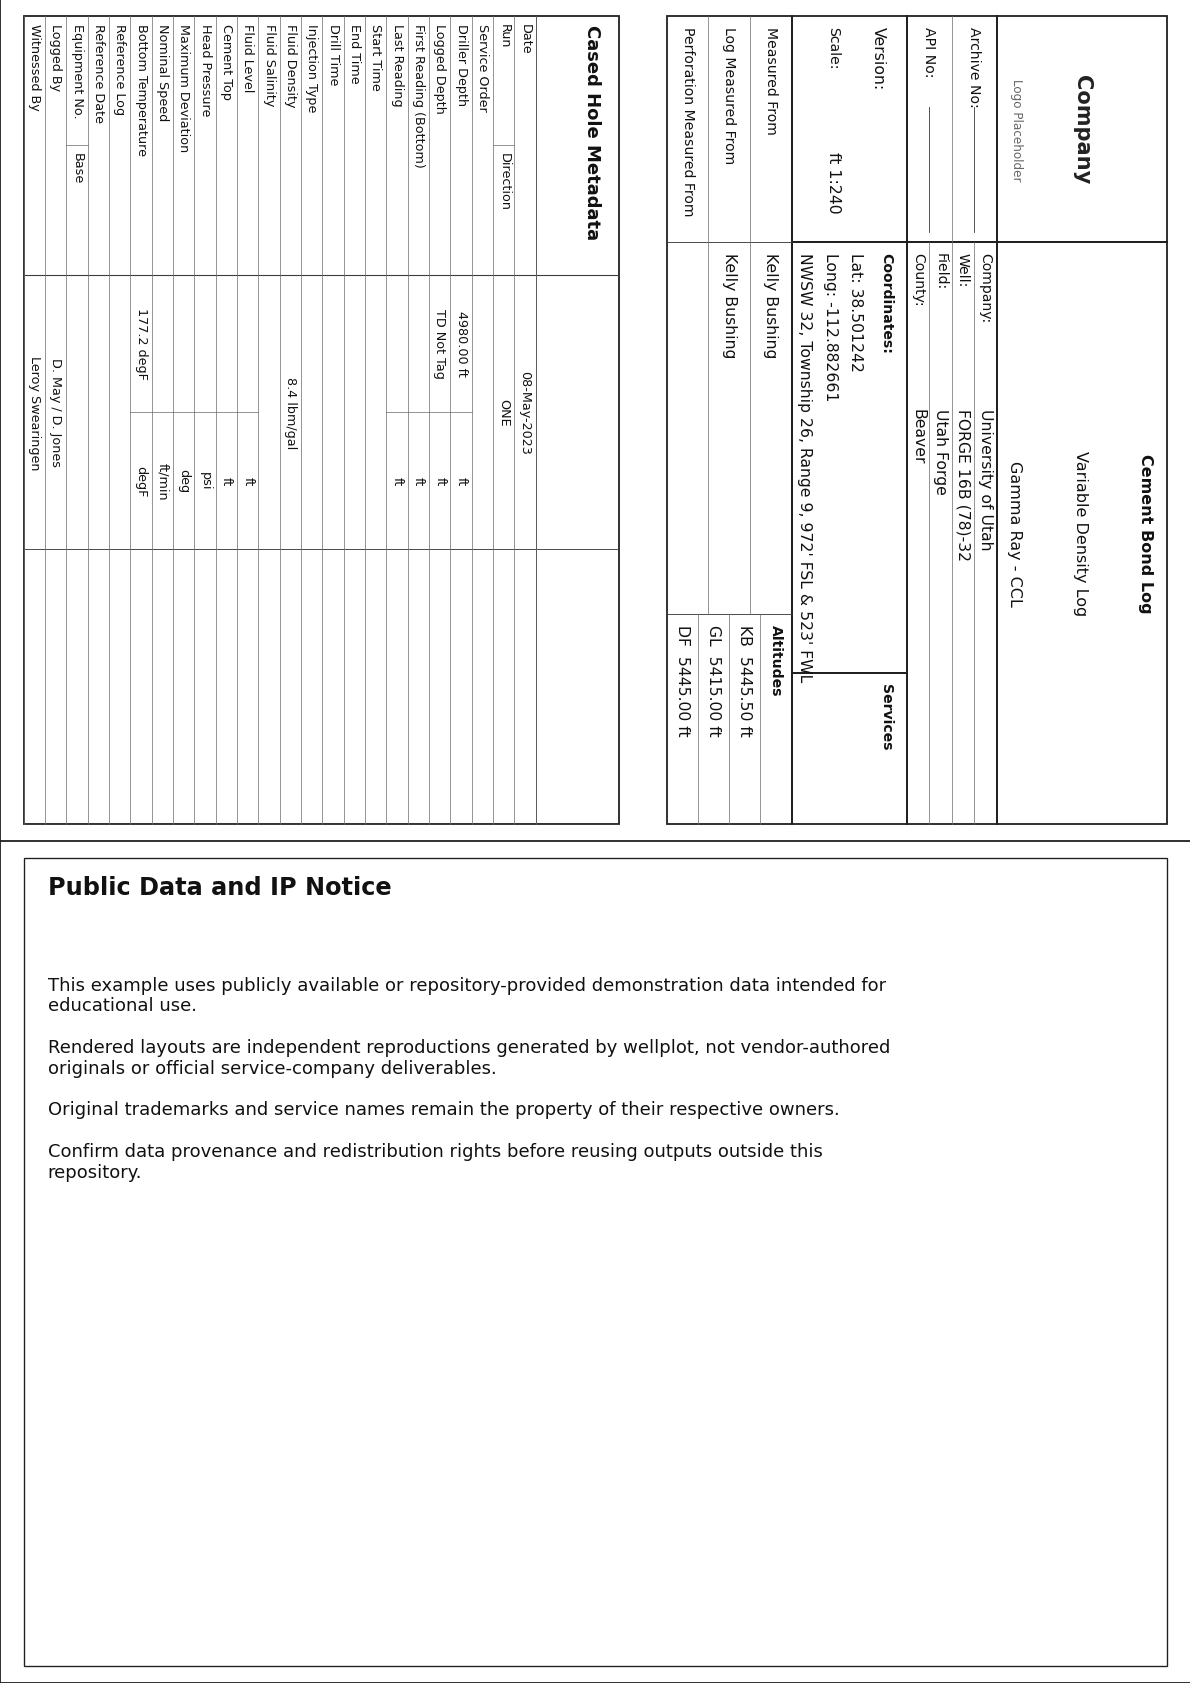

Diagnostic tool calls: 62
inspect_authoring calls: 19
Stable outcomes: total= 62 successful= 61 failed= 1


In [7]:
import sys
from importlib import import_module

sys.path.insert(0, str(REPO_ROOT))
verify_cbl_packet = import_module("scripts.verify_cbl_packet").verify_cbl_packet

reconstruction_result = await session.run(
    goal=TARGET_PROMPT,
    source_logfile_path=STARTER_LOGFILE,
)

acceptance = verify_cbl_packet(DRAFT_LOGFILE)
if not acceptance["ok"]:
    details = "\n".join(f" - {error}" for error in acceptance["errors"])
    raise RuntimeError(f"CBL packet acceptance failed before display or render:\n{details}")

display_authoring_result(
    "CBL reconstruction from one prompt",
    reconstruction_result,
    preview="report",
    include_phase_previews=True,
)

trace_names = [call.name for call in reconstruction_result.tool_trace]
print("Diagnostic tool calls:", len(trace_names))
print("inspect_authoring calls:", trace_names.count("inspect_authoring"))
stable_outcomes = reconstruction_result.report_facts.get("stable_tool_outcomes", [])
if isinstance(stable_outcomes, list):
    failed_outcomes = [
        outcome
        for outcome in stable_outcomes
        if isinstance(outcome, dict)
        and isinstance(outcome.get("payload"), dict)
        and outcome["payload"].get("is_error") is True
    ]
    print("Stable outcomes: total=", len(stable_outcomes),
          "successful=", len(stable_outcomes) - len(failed_outcomes),
          "failed=", len(failed_outcomes))


In [11]:
print("CBL packet acceptance: final typed document, headers, remarks, sections, bindings, raster, and report settings verified.")
print("CBL packet YAML SHA-256:", acceptance["document_sha256"])

async with session.authoring_session.runtime.open_session() as mcp_session:
    preview_result = await mcp_session.call_tool(
        "preview_logfile",
        {"logfile_path": relative_path(DRAFT_LOGFILE, root=REPO_ROOT), "focus": "report"},
    )
if getattr(preview_result, "isError", False):
    raise RuntimeError(f"CBL packet preview failed: {preview_result}")
print("CBL packet visual preview: passed")

render_result = await session.render_logfile_to_file(overwrite=True)
render_result


{'backend': 'matplotlib',
 'page_count': 41,
 'output_path': '/home/user/projects/well_log_os/workspace/tutorials/agent_cbl_log_example_from_prompt/agent_cbl_log_example.pdf'}